<a href="https://colab.research.google.com/github/boharonlyfor22-cpu/Machine-learning-project/blob/main/ml2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install any missing libraries (Colab usually has these pre-installed)
# !pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

print('✅ All libraries imported successfully!')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')

✅ All libraries imported successfully!
  pandas  : 2.2.2
  numpy   : 2.0.2


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/student_dropout_dataset_v3.csv")
df

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()



✅ Dataset loaded: 10,000 rows × 19 columns


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
# Basic info
print('─' * 50)
print('DATASET INFO')
print('─' * 50)
df.info()
print()
print('─' * 50)
print('MISSING VALUES')
print('─' * 50)
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print('─' * 50)
print('TARGET DISTRIBUTION')
print('─' * 50)
print(df['Dropout'].value_counts())
print(f"\nDropout rate: {df['Dropout'].mean()*100:.1f}%")

──────────────────────────────────────────────────
DATASET INFO
──────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float

In [ ]:
# Statistical summary
df.describe().round(2)

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00,10000.00,9500.00,9500.00,10000.00,10000.00,10000.00,9500.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,21.03,38377.25,4.01,81.74,1.80,30.18,5.51,2.31,2.30,2.30,0.24
std,2886.90,2.14,20496.23,1.30,8.22,1.34,11.92,1.77,1.06,1.07,1.07,0.42
min,1.00,17.00,25000.00,0.50,38.20,0.00,5.00,1.00,0.00,0.00,0.00,0.00
25%,2500.75,19.50,25000.00,3.16,76.40,1.00,21.90,4.30,1.55,1.52,1.52,0.00
50%,5000.50,21.00,29740.50,4.00,81.80,2.00,30.20,5.50,2.35,2.35,2.35,0.00
75%,7500.25,22.50,44520.00,4.87,87.30,3.00,38.40,6.70,3.12,3.15,3.15,0.00
max,10000.00,29.60,316601.00,8.98,100.00,8.00,74.90,10.00,4.00,4.00,4.00,1.00


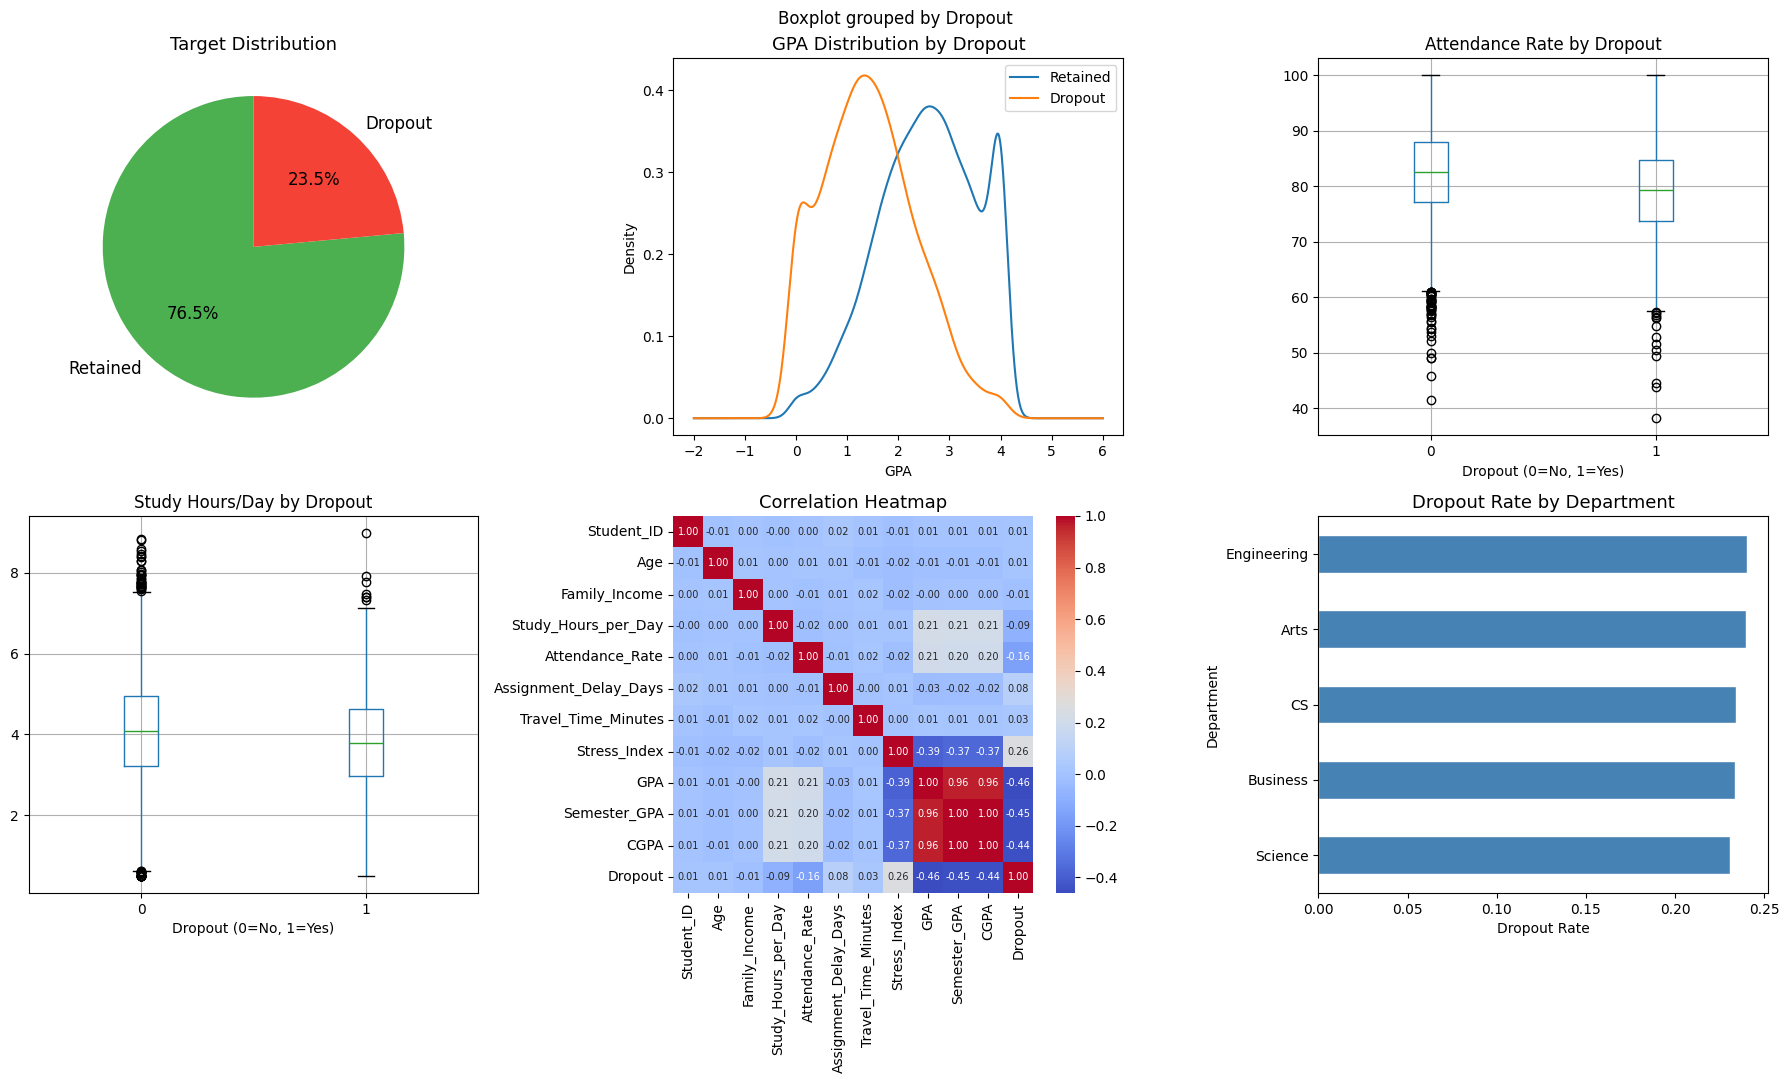

✅ EDA complete


In [ ]:
# ── EDA Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA — Student Dropout Dataset', fontsize=18, fontweight='bold', y=1.01)

# 1. Target pie chart
counts = df['Dropout'].value_counts()
axes[0, 0].pie(counts, labels=['Retained', 'Dropout'],
               autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
               startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Target Distribution', fontsize=13)

# 2. GPA KDE by dropout
for label, grp in df.groupby('Dropout'):
    grp['GPA'].plot(kind='kde', ax=axes[0, 1],
                    label='Dropout' if label == 1 else 'Retained')
axes[0, 1].set_title('GPA Distribution by Dropout', fontsize=13)
axes[0, 1].set_xlabel('GPA'); axes[0, 1].legend()

# 3. Attendance boxplot
df.boxplot(column='Attendance_Rate', by='Dropout', ax=axes[0, 2])
axes[0, 2].set_title('Attendance Rate by Dropout', fontsize=13)
axes[0, 2].set_xlabel('Dropout (0=No, 1=Yes)')
plt.sca(axes[0, 2]); plt.title('Attendance Rate by Dropout')

# 4. Study hours boxplot
df.boxplot(column='Study_Hours_per_Day', by='Dropout', ax=axes[1, 0])
axes[1, 0].set_title('Study Hours/Day by Dropout', fontsize=13)
axes[1, 0].set_xlabel('Dropout (0=No, 1=Yes)')
plt.sca(axes[1, 0]); plt.title('Study Hours/Day by Dropout')

# 5. Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 1], annot_kws={'size': 7}, cbar=True)
axes[1, 1].set_title('Correlation Heatmap', fontsize=13)

# 6. Dropout rate by department
dept = df.groupby('Department')['Dropout'].mean().sort_values()
dept.plot(kind='barh', ax=axes[1, 2], color='steelblue', edgecolor='white')
axes[1, 2].set_title('Dropout Rate by Department', fontsize=13)
axes[1, 2].set_xlabel('Dropout Rate')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA complete')

In [ ]:
# ── 4a. Drop non-predictive column
df.drop(columns=['Student_ID'], inplace=True)
print('✅ Dropped Student_ID')

# ── 4b. Separate features and target
X = df.drop(columns=['Dropout'])
y = df['Dropout']
print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Class balance  : {dict(y.value_counts())}')

✅ Dropped Student_ID
Features shape : (10000, 17)
Target shape   : (10000,)
Class balance  : {0: np.int64(7646), 1: np.int64(2354)}


In [ ]:
# ── 4c. Handle missing values
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

# Numeric → fill with median
num_imputer = SimpleImputer(strategy='median')
X[num_features] = num_imputer.fit_transform(X[num_features])

# Categorical → fill with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_features] = cat_imputer.fit_transform(X[cat_features])

print(f'✅ Missing values after imputation: {X.isnull().sum().sum()}')

✅ Missing values after imputation: 0


In [ ]:
# ── 4d. Encode categorical features
le = LabelEncoder()
for col in cat_features:
    X[col] = le.fit_transform(X[col])
    print(f'  Encoded: {col}')

print('\n✅ All categorical features encoded')
X.head()

  Encoded: Gender
  Encoded: Internet_Access
  Encoded: Part_Time_Job
  Encoded: Scholarship
  Encoded: Semester
  Encoded: Department
  Encoded: Parental_Education

✅ All categorical features encoded


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education
0,22.1,1,25000.0,1,3.36,86.1,2.0,20.4,1,0,5.5,0.96,0.90,0.90,0,0,1
1,20.7,1,25000.0,1,4.30,68.0,2.0,44.0,0,0,6.8,1.28,1.20,1.19,2,3,0
2,22.4,1,40183.0,1,4.40,70.9,0.0,48.9,1,0,5.5,1.68,1.32,1.32,0,0,2
3,24.4,1,29740.5,1,4.00,82.2,2.0,38.6,0,0,5.5,1.78,1.77,1.77,0,2,1
4,20.5,0,25319.0,1,4.19,75.7,1.0,23.0,0,0,7.0,1.48,0.91,0.87,3,1,0


In [ ]:
# ── 4e. Train / Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set : {X_train.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')

# ── 4f. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply to test
print('✅ StandardScaler applied (fit on train, transform on test)')

Train set : 8,000 samples
Test set  : 2,000 samples
✅ StandardScaler applied (fit on train, transform on test)


In [ ]:
# Define models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
}

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f'{'Model':<25} {'CV Accuracy':>12} {'Std':>8}')
print('─' * 48)

for name, model in models.items():
    data = X_train_scaled if name in ['Logistic Regression', 'SVM'] else X_train
    scores = cross_val_score(model, data, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}      ±{scores.std():.4f}')

Model                      CV Accuracy      Std
────────────────────────────────────────────────
Logistic Regression       0.8080      ±0.0038
Decision Tree             0.7672      ±0.0104
Random Forest             0.8031      ±0.0045
Gradient Boosting         0.8021      ±0.0054
SVM                       0.8040      ±0.0029


In [ ]:
test_results = {}

for name, model in models.items():
    is_scaled = name in ['Logistic Regression', 'SVM']
    Xtr = X_train_scaled if is_scaled else X_train
    Xte = X_test_scaled  if is_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    test_results[name] = {'accuracy': acc, 'roc_auc': auc,
                          'y_pred': y_pred, 'y_prob': y_prob}

    print(f'\n{'═'*45}')
    print(f'  Model : {name}')
    print(f'  Acc   : {acc:.4f}   |   ROC-AUC : {auc:.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['Retained', 'Dropout']))


═════════════════════════════════════════════
  Model : Logistic Regression
  Acc   : 0.8120   |   ROC-AUC : 0.8206
              precision    recall  f1-score   support

    Retained       0.84      0.94      0.88      1529
     Dropout       0.67      0.40      0.50       471

    accuracy                           0.81      2000
   macro avg       0.75      0.67      0.69      2000
weighted avg       0.80      0.81      0.79      2000


═════════════════════════════════════════════
  Model : Decision Tree
  Acc   : 0.7690   |   ROC-AUC : 0.7151
              precision    recall  f1-score   support

    Retained       0.82      0.90      0.86      1529
     Dropout       0.51      0.36      0.42       471

    accuracy                           0.77      2000
   macro avg       0.67      0.63      0.64      2000
weighted avg       0.75      0.77      0.75      2000


═════════════════════════════════════════════
  Model : Random Forest
  Acc   : 0.8030   |   ROC-AUC : 0.7996
       

In [ ]:
# Select best model by ROC-AUC
best_name = max(test_results, key=lambda k: test_results[k]['roc_auc'])
best = test_results[best_name]

print(f'🏆 Best model  : {best_name}')
print(f'   ROC-AUC    : {best["roc_auc"]:.4f}')
print(f'   Accuracy   : {best["accuracy"]:.4f}')

🏆 Best model  : Logistic Regression
   ROC-AUC    : 0.8206
   Accuracy   : 0.8120


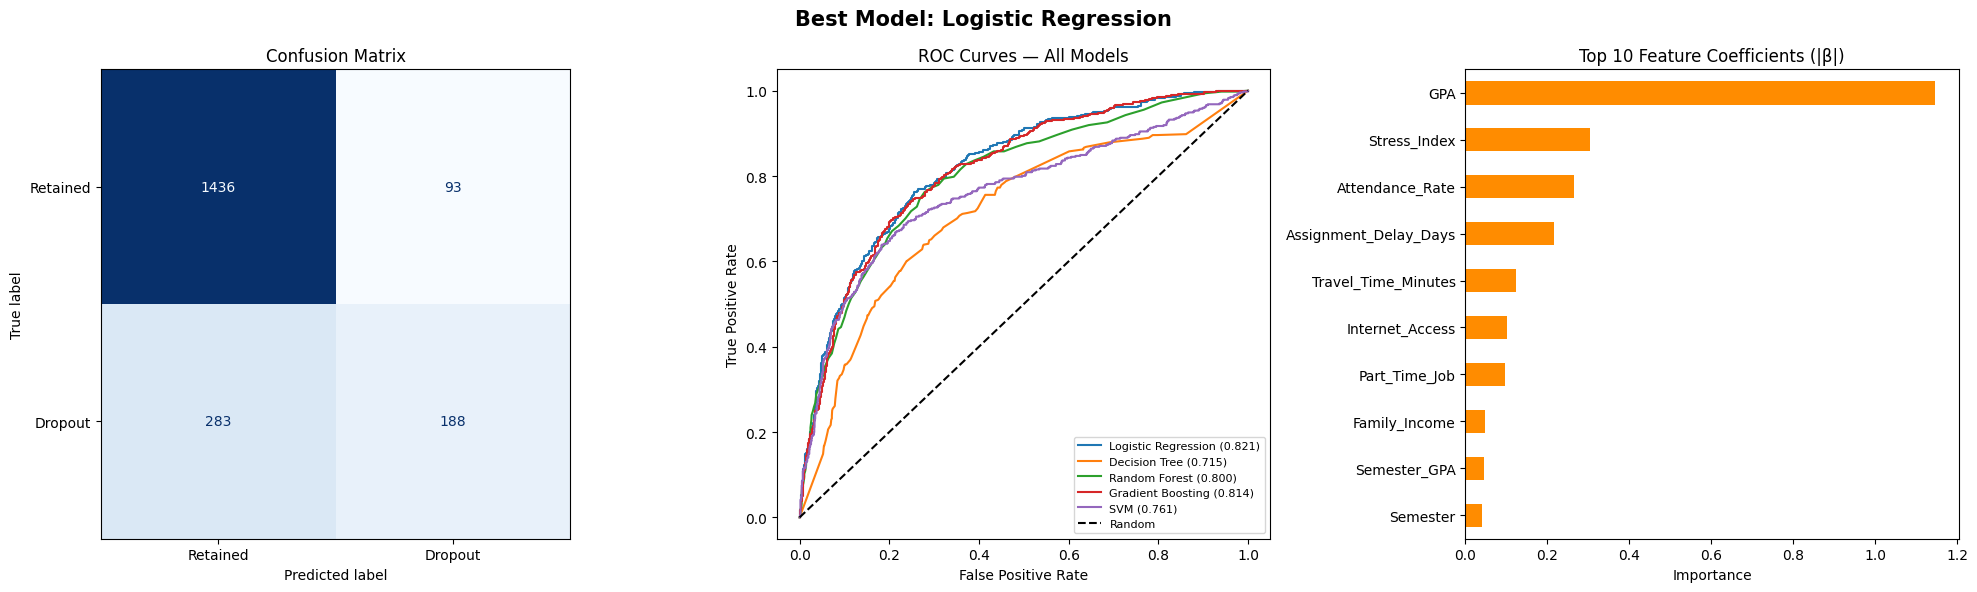

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Best Model: {best_name}', fontsize=15, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Dropout']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 2. ROC Curves — all models
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} ({res['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(fontsize=8)

# 3. Feature Importance
best_model = models[best_name]
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns)
    title = 'Feature Importances'
else:
    fi = pd.Series(best_model.coef_[0], index=X.columns).abs()
    title = 'Feature Coefficients (|β|)'
fi.nlargest(10).sort_values().plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title(f'Top 10 {title}')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('model_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
comparison = pd.DataFrame({
    name: {
        'CV Accuracy': cv_results[name].mean(),
        'CV Std':      cv_results[name].std(),
        'Test Acc':    test_results[name]['accuracy'],
        'ROC-AUC':     test_results[name]['roc_auc'],
    }
    for name in models
}).T.round(4)

comparison = comparison.sort_values('ROC-AUC', ascending=False)
print('Model Comparison (sorted by ROC-AUC):')
comparison.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc')

Model Comparison (sorted by ROC-AUC):


,CV Accuracy,CV Std,Test Acc,ROC-AUC
Logistic Regression,0.808000,0.003800,0.812000,0.820600
Gradient Boosting,0.802100,0.005400,0.805500,0.814200
Random Forest,0.803100,0.004500,0.803000,0.799600
SVM,0.804000,0.002900,0.804500,0.761000
Decision Tree,0.767200,0.010400,0.769000,0.715100


In [ ]:
# ── Fill in a new student's details
new_student = pd.DataFrame([{
    'Age'                  : 20,
    'Gender'               : 1,     # 0=Female, 1=Male (after encoding)
    'Family_Income'        : 25000,
    'Internet_Access'      : 1,     # 1=Yes, 0=No
    'Study_Hours_per_Day'  : 2.0,
    'Attendance_Rate'      : 55.0,
    'Assignment_Delay_Days': 8,
    'Travel_Time_Minutes'  : 45,
    'Part_Time_Job'        : 1,     # 1=Yes, 0=No
    'Scholarship'          : 0,     # 1=Yes, 0=No
    'Stress_Index'         : 8.5,
    'GPA'                  : 2.1,
    'Semester_GPA'         : 1.9,
    'CGPA'                 : 2.0,
    'Semester'             : 1,     # Semester number (encoded)
    'Department'           : 2,     # Encoded department
    'Parental_Education'   : 0,     # Encoded education level
}])

# Predict
is_scaled = best_name in ['Logistic Regression', 'SVM']
data_in   = scaler.transform(new_student) if is_scaled else new_student

pred = best_model.predict(data_in)[0]
prob = best_model.predict_proba(data_in)[0][1]

label = '⚠️  LIKELY TO DROPOUT' if pred == 1 else '✅ LIKELY TO STAY ENROLLED'
print(f'Prediction         : {label}')
print(f'Dropout Probability: {prob:.2%}')
print(f'Model used         : {best_name}')

Prediction         : ⚠️  LIKELY TO DROPOUT
Dropout Probability: 78.04%
Model used         : Logistic Regression
